In [1]:
import sys
from tqdm import tqdm

import numpy as np
import torch
import matplotlib.pyplot as plt

from src.processor import Processor
from main import init_parser, update_parameters

In [2]:
parser = init_parser()
evaluation_case = 'CV'
sys.argv = ['notebook_cell', '--config', './config/ntu60/ntu60_jupyter.yaml', '--case', evaluation_case]
args = parser.parse_args()
args = update_parameters(parser, args)  # cmd > yaml > default

In [3]:
# aligned
args_aligned = args
args_aligned.alignment = 'aligned'
p_aligned = Processor(args_aligned)

[ 2026-04-24 14:02:00,892 ] Saving folder path: ./workdir/ntu_smv/config/ntu60/ntu60_jupyter/2026-04-24 14-02-00
[ 2026-04-24 14:02:00,892 ] 
[ 2026-04-24 14:02:00,898 ] Saving model name: Trans-GCN_ntu60
[ 2026-04-24 14:02:01,102 ] Using aligned data.
[ 2026-04-24 14:02:27,928 ] Dataset: ntu60
[ 2026-04-24 14:02:27,929 ] Batch size: train-64, eval-128
[ 2026-04-24 14:02:27,930 ] Data shape (branch, channel, frame, joint, person): [1, 3, 64, 25, 2]
[ 2026-04-24 14:02:27,931 ] Number of action classes: 60
[ 2026-04-24 14:02:27,996 ] Model: Trans-GCN {'use_att': True, 'kernel_size': [3, 2], 'dilations': [2, 3], 'reduct_ratio': 2, 'use_gcn': False, 'so2_arg': {'heads': 8, 'angle_partitions': 6, 'rot_one_axis': False}}
[ 2026-04-24 14:02:29,426 ] Model profile: 0.57G FLOPs and 0.74M Parameters
[ 2026-04-24 14:02:30,673 ] Optimizer: SGD {'lr': 0.1, 'momentum': 0.9, 'nesterov': True, 'weight_decay': 0.0002}
[ 2026-04-24 14:02:30,674 ] LR_Scheduler: step {'max_epoch': 100, 'warm_up': 0, 'step

In [4]:
# unaligned
args_unaligned = args
args_unaligned.alignment = 'unaligned'
p_unaligned = Processor(args_unaligned)

[ 2026-04-24 14:02:30,697 ] Saving folder path: ./workdir/ntu_smv/config/ntu60/ntu60_jupyter/2026-04-24 14-02-30
[ 2026-04-24 14:02:30,698 ] 
[ 2026-04-24 14:02:30,702 ] Saving model name: Trans-GCN_ntu60
[ 2026-04-24 14:02:30,705 ] Using unaligned data.
[ 2026-04-24 14:03:23,881 ] Dataset: ntu60
[ 2026-04-24 14:03:23,886 ] Batch size: train-64, eval-128
[ 2026-04-24 14:03:23,887 ] Data shape (branch, channel, frame, joint, person): [1, 3, 64, 25, 2]
[ 2026-04-24 14:03:23,888 ] Number of action classes: 60
[ 2026-04-24 14:03:23,910 ] Model: Trans-GCN {'use_att': True, 'kernel_size': [3, 2], 'dilations': [2, 3], 'reduct_ratio': 2, 'use_gcn': False, 'so2_arg': {'heads': 8, 'angle_partitions': 6, 'rot_one_axis': False}}
[ 2026-04-24 14:03:24,890 ] Model profile: 0.57G FLOPs and 0.74M Parameters
[ 2026-04-24 14:03:25,154 ] Optimizer: SGD {'lr': 0.1, 'momentum': 0.9, 'nesterov': True, 'weight_decay': 0.0002}
[ 2026-04-24 14:03:25,155 ] LR_Scheduler: step {'max_epoch': 100, 'warm_up': 0, 'st

In [5]:
def ntu60_label_to_name(label: int) -> str:
    """
    Returns the NTU RGB+D 60 action name for a given label (0-59).

    Args:
        label (int): Action label in [0, 59]

    Returns:
        str: Action class name
    """
    ntu60_classes = [
        "drink water", #0
        "eat meal/snack", #1
        "brushing teeth", #2
        "brushing hair", #3
        "drop", #4
        "pickup", #5
        "throw", #6
        "sitting down", #7
        "standing up (from sitting position)", #8
        "clapping", #9
        "reading", #10
        "writing", #11
        "tear up paper", #12
        "wear jacket", #13
        "take off jacket", #14
        "wear a shoe", #15
        "take off a shoe", #16
        "wear on glasses", #17
        "take off glasses", #18
        "put on a hat/cap", #19
        "take off a hat/cap", #20
        "cheer up", #21
        "hand waving", #22
        "kicking something", #23
        "reach into pocket", #24
        "hopping (one foot jumping)", #25
        "jump up", #26
        "make a phone call/answer phone", #27
        "playing with phone/tablet", #28
        "typing on a keyboard", #29
        "pointing to something with finger", #30
        "taking a selfie", #31
        "check time (from watch)", #32
        "rub two hands together", #33
        "nod head/bow", #34
        "shake head", #35
        "wipe face", #36
        "salute", #37
        "put palms together", #38
        "cross hands in front (say stop)", #39
        "sneeze/cough", #40
        "staggering", #41
        "falling", #42
        "touch head (headache)", #43
        "touch chest (stomachache/heart pain)", #44
        "touch back (backache)", #45
        "touch neck (neckache)", #46
        "nausea or vomiting condition", #47
        "use a fan (with hand or paper)/feeling warm", #48
        "punching/slapping other person", #49
        "kicking other person", #50
        "pushing other person", #51
        "pat on back of other person", #52
        "point finger at the other person", #53
        "hugging other person", #54
        "giving something to other person", #55
        "touch other person's pocket", #56
        "handshaking", #57
        "walking towards each other", #58
        "walking apart from each other" #59
    ]

    if not (0 <= label < 60):
        raise ValueError("Label must be in the range [0, 59].")

    return ntu60_classes[label]


In [179]:
# --------------------------------------------------
# Helper: plot one skeleton on a given axis
# --------------------------------------------------
def plot_single_skeleton(ax, joints, connections, show_axis=False, title=None):
    """
    joints: (V, 3)
    """
    # joints
    ax.scatter(joints[:, 0], joints[:, 1], joints[:, 2], c="r", s=20)

    z_nodes = [0, 1]
    x_nodes = [0, 16]
    y_nodes = [0, 12]
    #---------------------------------------------
    if show_axis==999: # Don't print points
    # --- highlight specific joints ---
        # z-axis (green): joints 1 & 2
        ax.scatter(
            joints[z_nodes, 0],
            joints[z_nodes, 1],
            joints[z_nodes, 2],
            c="black",
            alpha=1.0,
            s=30
        )

        # x-axis (red): joints 1 & 17
        ax.scatter(
            joints[x_nodes, 0],
            joints[x_nodes, 1],
            joints[x_nodes, 2],
            c="black",
            alpha=1.0,
            s=30
        )

        # y-axis (red): joints 1 & 12
        ax.scatter(
            joints[y_nodes, 0],
            joints[y_nodes, 1],
            joints[y_nodes, 2],
            c="black",
            alpha=1.0,
            s=30
        )
    #---------------------------------------------

    # bones
    for i, j in connections:
        ax.plot(
            [joints[i, 0], joints[j, 0]],
            [joints[i, 1], joints[j, 1]],
            [joints[i, 2], joints[j, 2]],
            c="b",
            linewidth=2
        )

    if show_axis:
    #---------------------------------------------
    # --- arrows (using quiver) ---

        # z-axis arrow: 1 -> 2
        p1, p2 = joints[z_nodes[0]], joints[z_nodes[1]]
        vec_z = p2 - p1
        ax.quiver(
            p1[0], p1[1], p1[2],
            vec_z[0], vec_z[1], vec_z[2],
            color='green',
            linewidth=2
        )

        # y-axis arrow: 1 -> 12
        p1, p12 = joints[y_nodes[0]], joints[y_nodes[1]]
        vec_y = (p12 - p1)*5
        ax.quiver(
            p1[0], p1[1], p1[2],
            vec_y[0], vec_y[1], vec_y[2],
            color='black',
            linewidth=2
        )

        # x-axis arrow: 1 -> 17
        p1, p17 = joints[x_nodes[0]], joints[x_nodes[1]]
        vec_x = (p1 - p17)*5
        ax.quiver(
            p17[0], p17[1], p17[2],
            vec_x[0], vec_x[1], vec_x[2],
            color='pink',
            linewidth=2
        )
    #---------------------------------------------

    if title and (not show_axis):
        ax.set_title(title, fontsize=20)

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])
    ax.grid(False)

In [180]:
# --------------------------------------------------
# Main visualization
# --------------------------------------------------
def compare_aligned_unaligned(
    X_unaligned,
    X_aligned,
    connections,
    class_name: str,
    num_frames=4,
    axis_limit=None,
    show_axis=False,
    elev=20,
    azim=45,
    choose_frame=None
):
    """
    X_*: (T, M, V, 3)
    """

    # convert to numpy
    if isinstance(X_unaligned, torch.Tensor):
        X_unaligned = X_unaligned.cpu().numpy()
    if isinstance(X_aligned, torch.Tensor):
        X_aligned = X_aligned.cpu().numpy()

    # assume M=1
    X_unaligned = X_unaligned[:, 0]
    X_aligned = X_aligned[:, 0]

    T = X_unaligned.shape[0]

    # ---- choose evenly spaced frames ----
    if not choose_frame:
        frame_ids = np.linspace(0, T - 1, num_frames).astype(int)
    else:
        frame_ids = choose_frame

    # ---- compute shared axis limits ----
    if axis_limit is None:
        all_data = np.concatenate([X_unaligned, X_aligned], axis=0)
        mins = all_data.min(axis=(0, 1))
        maxs = all_data.max(axis=(0, 1))
        center = (mins + maxs) / 2
        radius = np.max(maxs - mins) / 2
    else:
        center = np.zeros(3)
        radius = axis_limit

    # ---- create figure ----
    fig = plt.figure(figsize=(4 * num_frames, 6))
    if not show_axis:
        fig.suptitle(f"{class_name}: Unaligned vs Aligned", fontsize=25)

    for col, t in enumerate(frame_ids):

        # -------- Top row: UNALIGNED --------
        ax = fig.add_subplot(2, num_frames, col + 1, projection="3d")
        joints = X_unaligned[t]

        plot_single_skeleton(
            ax,
            joints,
            connections,
            show_axis=show_axis,
            title=f"Unaligned\nFrame {t}"
        )

        ax.set_xlim(center[0] - radius, center[0] + radius)
        ax.set_ylim(center[1] - radius, center[1] + radius)
        ax.set_zlim(center[2] - radius, center[2] + radius)
        ax.view_init(elev=elev, azim=azim)

        # -------- Bottom row: ALIGNED --------
        ax = fig.add_subplot(2, num_frames, num_frames + col + 1, projection="3d")
        joints = X_aligned[t]

        plot_single_skeleton(
            ax,
            joints,
            connections,
            show_axis=show_axis,
            title=f"Aligned\nFrame {t}"
        )

        ax.set_xlim(center[0] - radius, center[0] + radius)
        ax.set_ylim(center[1] - radius, center[1] + radius)
        ax.set_zlim(center[2] - radius, center[2] + radius)
        ax.view_init(elev=elev, azim=azim)

    plt.tight_layout()
    class_name = class_name.replace('/','_or_')
    plt.savefig(f"zz_ablatn_images/aligned_vs_unaligned_{class_name}{'' if not show_axis else '--axis'}.png", dpi=300)
    plt.show()

In [181]:
def get_sample(p, seed=None, class_idx=None, count=None, split='train'):
    
    if seed is not None:
        np.random.seed(seed)
    
    num = np.random.randint(low=0, high=234)

    loader = p.train_loader if split=='train' else p.eval_loader
    iter = tqdm(loader, dynamic_ncols=True)
    for i, (x_, y_) in enumerate(iter):
        # Using GPU
        for j in range(len(y_)):
            x = x_[j][0].float() # shape: C, T, V, M
            x = x.permute(1,3,2,0) # shape: T, M, V, C
            y = y_[j].item()
            class_name = ntu60_label_to_name(y) # class name

            if class_idx is not None:
                if y == class_idx:
                    if count is None:
                        return x, class_name
                    else:
                        count -= 1
                        if count == 0:
                            return x, class_name
            elif i == num:
                break # we just need one sample

    return x, class_name

In [182]:
# (source, target) joint connections based on NTU-RGB+D skeleton structure
NTU_CONNECTIONS = [
    (1, 2), (2, 21), (3, 21), (4, 3), (5, 21),
    (6, 5), (7, 6), (8, 7), (9, 21), (10, 9),
    (11, 10), (12, 11), (13, 1), (14, 13), (15, 14),
    (16, 15), (17, 1), (18, 17), (19, 18), (20, 19),
    (22, 23), (23, 8), (24, 25), (25, 12)
]

NTU_CONNECTIONS = [(i-1, j-1) for i,j in NTU_CONNECTIONS]

In [183]:
class_idx = 7 # 7: sitting, 8: standing
count = 189 # the first appearance of the class after seen for "count" number of times
split = 'train'
# get same sample (you must ensure same index!)
x_unaligned, y = get_sample(p=p_unaligned, class_idx=class_idx, count=count, split=split)
x_aligned, _ = get_sample(p=p_aligned, class_idx=class_idx, count=count, split=split)

# reshape like before
X_unaligned = x_unaligned[:, 0].unsqueeze(1)  # (T,1,V,3)
X_aligned   = x_aligned[:, 0].unsqueeze(1)


 33%|███▎      | 194/588 [00:02<00:05, 74.63it/s] 


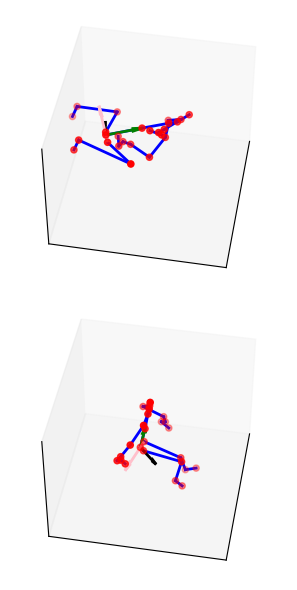

In [184]:
compare_aligned_unaligned(
    X_unaligned,
    X_aligned,
    connections=NTU_CONNECTIONS,
    class_name= ntu60_label_to_name(class_idx),
    num_frames=1,
    axis_limit=None,
    show_axis=True,
    choose_frame=[50],
    azim=10,
    elev=45
)